In [1]:
import os
import re
import math
import glob
import time
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pandas as pd
import csv

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from models.model_components import CALoRa
# You may need scipy for loading .mat files
try:
    from scipy.io import loadmat
except Exception as e:
    print("[INFO] scipy not found. Please install via `pip install scipy`. Loading .mat will fail without it.")
torch.cuda.empty_cache()

In [2]:
# Define dummy options class for maskCNNModel
class Opts:
    # LoRa Configuration
    sf=7
    fs = 1e6
    bw = 125e3
    n_classes = int(2**sf)      # 128
    
    # Model Configuration
    x_image_channel = 2
    y_image_channel = 2
    batch_size = 16
    normalization = True
    conv_dim_out_ = n_classes
    conv_dim_lstm_ = n_classes * 8

    # Spectrogram Configuration
    stft_nfft = int(n_classes * fs // bw)
    stft_window = int(n_classes // 2)
    stft_overlap = stft_window // 2
    freq_size = n_classes
    
    # Chirp Configuration
    code_list = [round(i, 1) for i in list(np.arange(0, n_classes, 0.1))]
    snr_list = list(range(-40, 16))
    bw_list = [125000]
    sf_list = [sf]
    instance_list = list(range(0, 7))
    feature_name = 'chirp'
    groundtruth_code = 35

opts = Opts()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# -------------------------------
# 0. Config
# -------------------------------
@dataclass
class TrainConfig:
    # Data roots per SF (adjust as needed)
    roots: Dict[int, str] = None
    target_width: int = 660         # W
    target_heights: Tuple[int, ...] = (128, 256, 512)  # supported H values
    preamble_len: int = 264         # L (for SF7; adjust map below for other SF)
    batch_size: int = 32
    num_workers: int = 1
    epochs: int = 1
    lr: float = 1e-4
    weight_decay: float = 1e-4
    amp: bool = True
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    # L candidates per SF (0.8x, 1.0x, 1.2x of 8*cols_per_symbol)
    L_map: Dict[int, Tuple[int, int, int]] = None
    # RCC / augmentation
    rcc_pad_mode: str = 'noise'
    use_aug: bool = True

# Data Path : (Resotred Preamble-embedded Spectrogram) Path
cfg = TrainConfig(
    roots={
        7: [
            './data_symbol/preamble_train/sf7/test_spec_/',      # Clean Data (기존)
            './data_symbol/preamble_train/sf7/test_spec_cfo/'   # CFO Augmented Data (추가)
        ],
        8: [
            './data_symbol/preamble_train/sf8/test_spec_/',      # Clean Data (기존)
            './data_symbol/preamble_train/sf8/test_spec_cfo/'   # CFO Augmented Data (추가)
        ],
        9: [
            './data_symbol/preamble_train/sf9/test_spec_/',      # Clean Data (기존)
            './data_symbol/preamble_train/sf9/test_spec_cfo/'   # CFO Augmented Data (추가)
        ]
    },
    L_map={
        7: (262,264,266),
        8: (262,264,266),
        9: (262,264,266),
    }
)

In [4]:
# -------------------------------
# 1. Utilities: filename parsing, IQ loading, spectrogram
# -------------------------------
FNAME_RE = re.compile(
    r'^'
    r'(?P<symidx>\d+)_'
    r'(?P<snr>-?\d+)_'
    r'(?P<sf>\d+)_'
    r'(?P<bw>\d+)_'
    r'0_'
    r'(?P<val>[\[\]0-9,\s-]+)'   # 정수 또는 [정수, ...] 리스트
    r'_0_0\.mat$'
)


def parse_filename(path: str):
    base = os.path.basename(path)
    m = FNAME_RE.match(base)
    if not m:
        raise ValueError(f"Unexpected filename format: {base}")
    dd = m.groupdict()
    # val: 정수 또는 리스트
    val_str = dd['val'].strip()
    if val_str.startswith('['):
        try:
            val = ast.literal_eval(val_str)   # -> list[int]
        except Exception:
            # 공백/형식 이슈 대비: 대괄호 제거 후 수동 파싱
            val = [int(x) for x in val_str.strip('[]').split(',') if x.strip()]
    else:
        val = int(val_str)
    return {
        'sym_index': int(dd['symidx']),
        'snr': int(dd['snr']),
        'sf': int(dd['sf']),
        'bw': int(dd['bw']),
        'val': val,               # int 또는 list[int]
        'fname': base,
    }


def load_chirp_spec_mat(path: str, expected_shape=(opts.n_classes, 660)) -> np.ndarray:
    md = loadmat(path)
    if 'chirp' not in md:
        raise KeyError(f"'chirp' key not found in {path}")
    spec = md['chirp']
    if spec.shape != expected_shape:
        raise ValueError(f"Expected {expected_shape}, got {spec.shape} in {path}")
    return spec.astype(np.float32)


def torch_spectrogram_from_iq(iq: np.ndarray, target_H: int, target_W: int,
                              window: str = 'hann') -> np.ndarray:
    """Compute magnitude spectrogram with precise target (H, W) using torch.stft.
    - Chooses n_fft so that n_freq = target_H (n_fft = 2*(H-1))
    - Chooses hop_length to hit target_W frames exactly (or within 1)
    Returns float32 array of shape (H, W).
    """
    x = torch.from_numpy(np.stack([iq.real, iq.imag], axis=0)).float()  # (2, N)
    # Convert complex IQ to single real by magnitude (or do complex STFT channel-wise and combine)
    # Here we compute STFT over complex-valued by applying to real and imag then combining magnitude
    def _stft_mag(sig_1d: torch.Tensor, n_fft: int, hop: int, win):
        st = torch.stft(sig_1d, n_fft=n_fft, hop_length=hop, window=win, return_complex=True)
        return torch.abs(st)  # (freq, time)

    n_fft = 2 * (target_H - 1)
    N = x.shape[1]
    hop = max(1, (N - n_fft) // max(1, (target_W - 1)))
    win = torch.hann_window(n_fft) if window == 'hann' else None

    mag_r = _stft_mag(x[0], n_fft, hop, win)
    mag_i = _stft_mag(x[1], n_fft, hop, win)
    mag = torch.sqrt(mag_r**2 + mag_i**2)  # combine real/imag magnitudes

    H, W = mag.shape[0], mag.shape[1]
    # Resize (if one-off mismatch) using bilinear on (1,1,H,W)
    if H != target_H or W != target_W:
        mag = F.interpolate(mag.unsqueeze(0).unsqueeze(0), size=(target_H, target_W), mode='bilinear', align_corners=False).squeeze()
    mag = torch.log1p(mag)  # log scaling
    mag = mag.numpy().astype(np.float32)
    # Normalize per-image
    mu, sigma = float(mag.mean()), float(mag.std() + 1e-6)
    mag = (mag - mu) / sigma
    # scale 0..1 (optional): here keep standardized; model is robust either way
    return mag

In [5]:
def rcc_crop(spec: np.ndarray, L: int = 264, W: int = 660,
             pad_mode: str = 'noise', rng: Optional[np.random.Generator] = None):
    """Randomize preamble location while guaranteeing full inclusion.
    spec: (H, 660) -> returns (spec_crop(H,660), y_mask(660), (t_start, t_end))
    """
    assert spec.ndim == 2 and spec.shape[1] == W
    H, _ = spec.shape
    R = W - L
    rng = np.random.default_rng() if rng is None else rng

    # 좌우 패딩 생성
    if pad_mode == 'noise':
        mu, sigma = float(spec.mean()), float(spec.std() + 1e-6)
        left_pad  = rng.normal(mu, sigma, size=(H, R)).astype(spec.dtype)
        right_pad = rng.normal(mu, sigma, size=(H, R)).astype(spec.dtype)
    elif pad_mode == 'edge':
        left_pad  = np.repeat(spec[:, :1], R, axis=1)
        right_pad = np.repeat(spec[:, -1:], R, axis=1)
    else:
        left_pad  = np.zeros((H, R), dtype=spec.dtype)
        right_pad = np.zeros((H, R), dtype=spec.dtype)

    # 캔버스 구성
    canvas = np.concatenate([left_pad, spec, right_pad], axis=1)  # (H, 1452)
    k_abs = R  # 원본 프리앰블 시작은 0 -> 캔버스에서는 R

    # 윈도우 내 프리앰블 시작 위치 k 선택, 그리고 포함을 보장하는 창 시작 c 선택
    k = rng.integers(low=0, high=W - L + 1)
    c = rng.integers(low=k - (W - L), high=k + 1)

    # 크롭
    c_abs = k_abs - k + c
    spec_crop = canvas[:, c_abs:c_abs + W]

    # 라벨
    y_mask = np.zeros(W, dtype=np.float32)
    t_start, t_end = int(k), int(k + L - 1)
    y_mask[t_start:t_end + 1] = 1.0

    return spec_crop.astype(np.float32), y_mask, (t_start, t_end)


In [6]:
# -------------------------------
# 3. Dataset
# -------------------------------
def load_chirp_spec_mat(path: str, expected_shape):
    md = loadmat(path)
    spec = md['chirp']  # (H,660)
    if spec.shape != expected_shape:
        raise ValueError(f"Expected {expected_shape}, got {spec.shape} in {path}")
    return spec.astype(np.float32)

class PreambleDataset(Dataset):
    def __init__(self, file_list, target_W, target_H, L_candidates, use_aug=True):
        self.files = list(file_list)
        self.W = target_W
        self.H = target_H
        self.Ls = L_candidates
        self.L  = int(np.median(self.Ls))
        self.use_aug = use_aug # True일 때 Augmentation 적용

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        spec = load_chirp_spec_mat(path, expected_shape=(self.H, self.W))
        
        # 라벨 초기화 (기본 위치)
        t_start, t_end = 0, 264  # 프리앰블 길이 (SF7 기준)
        
        # --- [Augmentation] ---
        if self.use_aug:
            # 1. Frequency Shift (CFO) - 기존 적용
            max_f_shift = int(self.H * 0.1) 
            shift_f = np.random.randint(-max_f_shift, max_f_shift + 1)
            spec = np.roll(spec, shift_f, axis=0)

            # 2. Time Shift (STO) - [새로 추가!] ⭐
            # 시간 축으로 ±20 픽셀 정도 흔들어 줍니다.
            max_t_shift = 20 
            shift_t = np.random.randint(-max_t_shift, max_t_shift + 1)
            
            # 스펙트로그램 이동 (좌우로 밀기)
            spec = np.roll(spec, shift_t, axis=1)
            
            # [중요] 라벨(정답지)도 같이 이동시켜야 함!
            t_start += shift_t
            t_end   += shift_t

        # 표준화
        spec_t = torch.from_numpy(spec)
        mu, sigma = float(spec_t.mean()), float(spec_t.std() + 1e-6)
        spec_t = (spec_t - mu) / sigma
        
        x = spec_t.unsqueeze(0).float()
        
        # 라벨 생성 (이동된 위치 반영)
        y = torch.zeros(self.W, dtype=torch.float32)
        
        # 인덱스가 이미지 범위를 벗어나지 않도록 클리핑 (Clipping)
        valid_start = max(0, min(self.W, t_start))
        valid_end   = max(0, min(self.W, t_end))
        
        # 유효한 구간에만 1.0 마킹
        if valid_start < valid_end:
            y[valid_start:valid_end] = 1.0
            
        return x, y, {"path": path}

In [7]:
# -------------------------------
# 4. Model (ColumnNetV2 + TemporalTCN)
# -------------------------------
class DSBlock(nn.Module):
    def __init__(self, cin, cout, k=(5,3)):
        super().__init__()
        self.dw = nn.Conv2d(cin, cin, k, padding=(k[0]//2, k[1]//2), groups=cin, bias=False)
        self.pw = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.act = nn.ReLU(inplace=True)
        self.res = (cin == cout)
    def forward(self, x):
        y = self.pw(self.dw(x))
        y = self.act(self.bn(y))
        return y + x if self.res else y

class ColumnNetV2(nn.Module):
    def __init__(self, C=64):
        super().__init__()
        # ... (기존 self.stem 동일) ...
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            DSBlock(16, 16, k=(5,3)),
            DSBlock(16, 32, k=(5,3)),
            DSBlock(32, C,  k=(5,3))
        )
        # [수정] 두 가지 Pooling을 모두 준비
        self.pool_max = nn.AdaptiveMaxPool2d((1, None))
        self.pool_avg = nn.AdaptiveAvgPool2d((1, None))
        
    def forward(self, x):
        f = self.stem(x)
        
        # [수정] Max와 Avg를 각각 수행
        f_max = self.pool_max(f).squeeze(2) # (B, C, W)
        f_avg = self.pool_avg(f).squeeze(2) # (B, C, W)
        
        # [수정] 채널 방향(dim=1)으로 이어 붙이기 (Concatenate)
        # 결과 채널 수: C + C = 2C (즉, 128개)
        f_cat = torch.cat([f_max, f_avg], dim=1) 
        return f_cat

class TemporalTCN(nn.Module):
    def __init__(self, C=32):
        super().__init__()
        def blk(d):
            return nn.Sequential(
                nn.Conv1d(C, C, kernel_size=3, padding=d, dilation=d, bias=False),
                nn.BatchNorm1d(C), nn.ReLU(inplace=True)
            )
        self.net = nn.Sequential(blk(1), blk(2), blk(4), blk(8), blk(16))
        self.head = nn.Conv1d(C, 1, 1)
    def forward(self, f):
        h = self.net(f)
        logits = self.head(h).squeeze(1)  # (B,W)
        return logits

class PreambleDetectorV2(nn.Module):
    def __init__(self, C=32, Ls: Tuple[int, ...] = (264,)):
        super().__init__()
        self.col = ColumnNetV2(C)
        # self.tem = TemporalTCN(C)
        # self.register_buffer('Ls', torch.tensor(Ls, dtype=torch.int64))
        self.tem = TemporalTCN(C*2)
        self.register_buffer('Ls', torch.tensor(Ls, dtype=torch.int64))
    @torch.no_grad()
    def _sliding_sum(self, p: torch.Tensor, L: int):
        cs = torch.cumsum(p, dim=-1)
        s = cs[:, L-1:] - F.pad(cs[:, :-L], (1, 0), value=0.0)
        return s
    def forward(self, x):
        f = self.col(x)                 # (B,C,W)
        logits = self.tem(f)            # (B,W)
        p = torch.sigmoid(logits)       # (B,W)
        sums = [self._sliding_sum(p, int(L)) for L in self.Ls.tolist()]
        # Pad sums to same width
        maxW = max(si.shape[1] for si in sums)
        sums = [F.pad(si, (0, maxW - si.shape[1])) for si in sums]
        s = torch.stack(sums, dim=1).amax(dim=1)  # (B, maxW)
        return logits, p, s

- After SF8

In [ ]:
# SE-Block 정의 (가벼운 Attention 모듈)
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x) # 채널별 중요도 곱하기

# TemporalTCN 수정
class TemporalTCN(nn.Module):
    def __init__(self, C_in): # 입력 채널 수 (Hybrid라면 128)
        super().__init__()
        
        # [추가] 입력 특징을 정제하는 Attention
        self.se_block = SEBlock(C_in)
        
        # TCN 블록들 (입력 채널 C_in 유지)
        def blk(d):
            return nn.Sequential(
                nn.Conv1d(C_in, C_in, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm1d(C_in), nn.ReLU(inplace=True)
            )
        
        self.net = nn.Sequential(
            blk(1), blk(2), blk(4), blk(8), 
            blk(16), blk(32), blk(64) # RF 확보용
        )
        self.head = nn.Conv1d(C_in, 1, 1)

    def forward(self, f):
        # [적용] TCN 들어가기 전에 Attention으로 노이즈 필터링
        f = self.se_block(f) 
        h = self.net(f)
        logits = self.head(h).squeeze(1)
        return logits

In [8]:
# -------------------------------
# 5. Losses & Metrics
# -------------------------------
class SoftIoU(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
    def forward(self, p: torch.Tensor, y: torch.Tensor):
        # p,y: (B,W) probability and binary mask
        inter = (p * y).sum(dim=1)
        union = (p + y - p*y).sum(dim=1) + self.eps
        iou = inter / union
        return 1.0 - iou.mean()

@torch.no_grad()
def interval_from_sums(s: torch.Tensor, L: int):
    # s: (B, W') sliding sums; return start,end in original W scale (approx)
    tau = torch.argmax(s, dim=-1)  # (B,)
    start = tau
    end = tau + (L - 1)
    return start, end

@torch.no_grad()
def metrics_from_probs(p: torch.Tensor, y: torch.Tensor, L: int):
    # Compute Hit@±1 sym and boundary MAE in columns
    B, W = p.shape
    s = torch.cumsum(p, dim=-1)
    s = s[:, L-1:] - F.pad(s[:, :-L], (1, 0), value=0.0)
    ps, pe = interval_from_sums(s, L)
    # GT from mask
    y_idx = y.nonzero(as_tuple=False)
    # Assume one contiguous interval per sample
    y_bounds = []
    for b in range(B):
        idx = y[b].nonzero(as_tuple=False).squeeze(1)
        if idx.numel() == 0:
            y_bounds.append((torch.tensor(0), torch.tensor(0)))
        else:
            y_bounds.append((idx[0], idx[-1]))
    ts = torch.stack([b[0] for b in y_bounds])
    te = torch.stack([b[1] for b in y_bounds])
    mae_s = (ps - ts).abs().float().mean().item()
    mae_e = (pe - te).abs().float().mean().item()
    hit_s = ((ps - ts).abs() <= 1).float().mean().item()
    hit_e = ((pe - te).abs() <= 1).float().mean().item()
    return {
        'MAE_start': mae_s,
        'MAE_end': mae_e,
        'Hit@±1_start': hit_s,
        'Hit@±1_end': hit_e,
    }

- Data Path : (Resotred Preamble-embedded Spectrogram) Path

In [9]:
import random
# -------------------------------
# 6. Build file lists per SF/height
# -------------------------------
def collect_files(root: str) -> list[str]:
    return sorted(glob.glob(os.path.join(root, '*.mat')))

sf_to_H = {7: 128, 8: 256, 9: 512}  # adjust if your spectrogram target H differs

all_loaders = {}

for sf, paths in cfg.roots.items():
    # 1. 단일 경로(str)만 적혀있을 경우 리스트로 변환 (호환성 유지)
    if isinstance(paths, str):
        paths = [paths]
        
    all_files = []
    
    # 2. 리스트에 있는 모든 폴더를 돌면서 파일 수집 (Aggregation)
    for root in paths:
        files_in_root = collect_files(root)
        all_files.extend(files_in_root)
        print(f"  -> SF{sf}: Found {len(files_in_root)} files in '{root}'")

    if not all_files:
        print(f"[WARN] No .mat files found for SF{sf}")
        continue

    # 3. [핵심] Clean 데이터와 CFO 데이터를 무작위로 섞음 (Shuffle)
    # 이걸 안 하면 앞쪽 폴더 데이터가 Validation으로, 뒤쪽 폴더가 Train으로 쏠릴 수 있음!
    random.seed(37) # 재현성을 위해 시드 고정 추천
    random.shuffle(all_files)
    
    # 4. Train / Validation Split
    n = len(all_files)
    n_val = max(1, int(0.1 * n)) # 10%를 검증용으로 사용
    
    val_files = all_files[:n_val]
    tr_files  = all_files[n_val:]
    
    print(f"  => SF{sf} Total: {n} (Train: {len(tr_files)}, Val: {len(val_files)})")

    # 5. DataLoader 생성 (기존과 동일)
    H = sf_to_H.get(sf, opts.n_classes) # opts.n_classes가 정의되어 있다고 가정
    
    # use_aug=cfg.use_aug: 학습 데이터에는 추가적인 Augmentation(마스킹 등) 적용 가능
    ds_tr  = PreambleDataset(tr_files, cfg.target_width, H, cfg.L_map[sf], use_aug=cfg.use_aug)
    # 검증 데이터는 원본 그대로 평가
    ds_val = PreambleDataset(val_files, cfg.target_width, H, cfg.L_map[sf], use_aug=False)
    
    ld_tr  = DataLoader(ds_tr,  batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=True)
    ld_val = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    
    all_loaders[sf] = (ld_tr, ld_val)

print("[Data Loading] Complete.\n")

  -> SF7: Found 0 files in './data_symbol/preamble_train/sf7/test_spec_/'
  -> SF7: Found 0 files in './data_symbol/preamble_train/sf7/test_spec_cfo/'
[WARN] No .mat files found for SF7
  -> SF8: Found 0 files in './data_symbol/preamble_train/sf8/test_spec_/'
  -> SF8: Found 0 files in './data_symbol/preamble_train/sf8/test_spec_cfo/'
[WARN] No .mat files found for SF8
  -> SF9: Found 0 files in './data_symbol/preamble_train/sf9/test_spec_/'
  -> SF9: Found 0 files in './data_symbol/preamble_train/sf9/test_spec_cfo/'
[WARN] No .mat files found for SF9
[Data Loading] Complete.



In [10]:
def append_metrics_csv(path, sf, epoch, tr_loss, val_loss, m_agg, dt):
    path = Path(path)
    is_new = not path.exists()

    fields = [
        "sf", "epoch", "tr_loss", "val_loss",
        "MAE_start", "MAE_end",
        "Hit@±1_start", "Hit@±1_end",
        "seconds"
    ]
    row = {
        "sf": sf,
        "epoch": int(epoch),
        "tr_loss": float(tr_loss),
        "val_loss": float(val_loss),
        "MAE_start": float(m_agg.get("MAE_start", math.nan)),
        "MAE_end": float(m_agg.get("MAE_end", math.nan)),
        "Hit@±1_start": float(m_agg.get("Hit@±1_start", math.nan)),
        "Hit@±1_end": float(m_agg.get("Hit@±1_end", math.nan)),
        "seconds": float(dt),
    }

    with path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        if is_new:
            writer.writeheader()
        writer.writerow(row)

In [ ]:
# -------------------------------
# Refactored Train Function for Fine-tuning
# -------------------------------
bce_lambda = 0.3
soft_iou_lambda = 0.7
def train_one_sf(sf: int, pretrained_path: str = None):
    print(f"\n===== Training SF{sf} (Fine-tuning Mode: {pretrained_path is not None}) =====")
    
    (ld_tr, ld_val) = all_loaders[sf]
    Ls = cfg.L_map[sf]
    
    # 1. 모델 초기화
    model = PreambleDetectorV2(C=64, Ls=Ls).to(cfg.device)
    
    # [수정 1] Pre-trained Weight 로딩
    if pretrained_path:
        if os.path.isfile(pretrained_path):
            print(f"Loading pretrained weights from: {pretrained_path}")
            checkpoint = torch.load(pretrained_path, map_location=cfg.device)
            state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
            print(" -> Weights loaded successfully.")
        else:
            print(f"Warning: Pretrained path {pretrained_path} not found. Training from scratch.")

    current_lr = cfg.lr
    print(f"Current Learning Rate: {current_lr}")
    
    opt = torch.optim.AdamW(model.parameters(), lr=current_lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5, verbose=True, threshold=1e-4
    )

    bce = nn.BCEWithLogitsLoss()
    soft_iou = SoftIoU()
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)

    best_val = float('inf')
    save_dir = f'ckpt_sf{sf}_finetune' if pretrained_path else f'ckpt_sf{sf}_2'
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, cfg.epochs+1):
        # --- Training ---
        model.train()
        loss_sum = 0.0
        t0 = time.time()
        
        for x, y, meta in ld_tr:
            x = x.to(cfg.device, non_blocking=True)
            y = y.to(cfg.device, non_blocking=True)
            
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=cfg.amp):
                logits, p, s = model(x)
                loss_bce = bce(logits, y)
                loss_iou = soft_iou(torch.sigmoid(logits), y)
                loss = bce_lambda * loss_bce + soft_iou_lambda * loss_iou
            
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            loss_sum += loss.item() * x.size(0)
            
        tr_loss = loss_sum / len(ld_tr.dataset)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        m_agg = {'MAE_start':0,'MAE_end':0,'Hit@±1_start':0,'Hit@±1_end':0}
        cnt = 0
        
        with torch.no_grad():
            for x, y, meta in ld_val:
                x = x.to(cfg.device, non_blocking=True)
                y = y.to(cfg.device, non_blocking=True)
                logits, p, s = model(x)
                
                loss = bce_lambda * bce(logits, y) + soft_iou_lambda * soft_iou(torch.sigmoid(logits), y)
                val_loss += loss.item() * x.size(0)
                
                m = metrics_from_probs(torch.sigmoid(logits), y, L=int(np.median(Ls)))
                for k in m_agg.keys():
                    m_agg[k] += m[k] * x.size(0)
                cnt += x.size(0)
        
        val_loss /= max(1, len(ld_val.dataset))
        for k in m_agg.keys():
            m_agg[k] /= max(1, cnt)

        dt = time.time()-t0
        
        scheduler.step(val_loss)
        curr_optim_lr = opt.param_groups[0]['lr']

        print(f"[SF{sf}][Ep {epoch:02d}] tr {tr_loss:.4f} | val {val_loss:.4f} | LR {curr_optim_lr:.1e} | "
              f"Hit(s) {m_agg['Hit@±1_start']:.2f} | {dt:.1f}s")
        
        append_metrics_csv(f"./{save_dir}/train_metrics.csv", sf, epoch, tr_loss, val_loss, m_agg, dt)
        
        # Best Model 저장
        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                'model': model.state_dict(), 
                'cfg': cfg.__dict__, 
                'sf': sf,
                'optimizer': opt.state_dict() # Optimizer 상태도 저장 추천
            }, f'{save_dir}/best_finetuned.pth')
            print(f"  -> Saved best model (Val Loss: {val_loss:.4f})")

    return model

# --- 실행 예시 ---
# 1. 기존에 학습 잘 된 모델 경로 (Clean Data로 학습한 것)
if opts.sf in all_loaders:
    _ = train_one_sf(opts.sf)

## Prediction

- SF7 : C=64 
- SF8 & SF9 : C=128
    - Using Another TemporalTCN Block (with SEBlock)

In [25]:
# ---- 1) 모델 로드 (학습 때와 동일한 클래스/하이퍼) ----
# 학습 코드에 이미 정의한 것과 동일해야 합니다: PreambleDetectorV2, ColumnNetV2, TemporalTCN
# (이미 커널에 정의돼 있다면 이 블록은 생략해도 됩니다)
# from your_module import PreambleDetectorV2   # 필요한 경우
opts.sf = opts.sf
opts.sf = 7
preamb_size = 264

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ckpt = torch.load(f'ckpt_sf{opts.sf}/best_{0.5}_{0.5}.pth', map_location='cpu')
ckpt = torch.load(f'../ckpt_sf{opts.sf}_2/best_finetuned.pth', map_location='cpu')
# ckpt = torch.load(f'ckpt_sf{opts.sf}_finetune/best_finetuned.pth', map_location='cpu')

# ckpt = torch.load(f'ckpt_sf{opts.sf}/best.pth', map_location='cpu')
Ls = tuple(int(x) for x in ckpt.get('cfg', {}).get('L_map', {opts.sf:(preamb_size,)}).get(ckpt.get('sf',opts.sf), (preamb_size,)))
if not Ls: Ls = (preamb_size,)
model = PreambleDetectorV2(C=64, Ls=Ls).to(device)
model.load_state_dict(ckpt['model'])
model.eval()

PreambleDetectorV2(
  (col): ColumnNetV2(
    (stem): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): DSBlock(
        (dw): Conv2d(16, 16, kernel_size=(5, 3), stride=(1, 1), padding=(2, 1), groups=16, bias=False)
        (pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
      (4): DSBlock(
        (dw): Conv2d(16, 16, kernel_size=(5, 3), stride=(1, 1), padding=(2, 1), groups=16, bias=False)
        (pw): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
      (5): DSBlock(
        (dw): Conv2d(32, 32, kernel

In [45]:
output_dir = f"../data_symbol/preamble_train/sf{opts.sf}/gen_symbol2_spec/"
# output_dir = f"./data_symbol/preamble_train/sf{opts.sf}/gen_symbol2_spec_cfo/"

# output_dir = f"../data_symbol/preamble_train/sf{opts.sf}/test2_spec_/"
# output_dir = f"./data_symbol/preamble_train/sf{opts.sf}/test_spec_cfo/"

mat_files = sorted(glob.glob(os.path.join(output_dir, "*.mat")))
print(mat_files[:7])
print(len(mat_files))


['../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-10_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 51, 81, -1, -1, 38, 63, 126, 28, 80, 30, 42, 71]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-11_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 91, 32, -1, -1, 103, 78, 11, 128, 119, 1, 8, 22]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-12_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 25, 40, -1, -1, 8, 26, 63, 118, 84, 58, 99, 73]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-13_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 16, 44, -1, -1, 64, 15, 113, 107, 108, 102, 28, 23]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-14_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 85, 16, -1, -1, 40, 109, 98, 89, 34, 54, 57, 63]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-15_7_125000_0_[0, 0, 0, 0, 0, 0, 0, 0, 95, 92, -1, -1, 73, 54, 55, 54, 72, 106, 97, 49]_0_0.mat', '../data_symbol/preamble_train/sf7/gen_symbol2_spec/100_-16_7_12500

In [34]:
# 공통된 상위 경로 (sf{opts.sf} 까지)
base_dir = f"../data_symbol/preamble_train/sf{opts.sf}"

# 1. 첫 번째 경로 (기존 cfo 폴더)
path_cfo = os.path.join(base_dir, "test2_spec_cfo", "*.mat")

# 2. 두 번째 경로 (추가하려는 test_spec_ 폴더)
path_spec = os.path.join(base_dir, "test2_spec_", "*.mat")

# 3. 두 리스트를 합치고(+) 정렬(sorted)
# glob.glob(path_cfo)와 glob.glob(path_spec)은 각각 리스트를 반환하므로 + 연산자로 합칠 수 있습니다.
mat_files = sorted(glob.glob(path_cfo) + glob.glob(path_spec))

print(f"총 파일 개수: {len(mat_files)}")

총 파일 개수: 6000


In [52]:
from collections import Counter
test_snrs_ = [i for i in range(-30,1)]
# test_snrs_ = [i for i in range(-40,-30)]
flattened = test_snrs_
# 고윳값 개수 세기
value_counts = Counter(flattened)
num_classes = 2 ** opts.sf
snr_min = -30
snr_max = 0

# snr_min = -40
# snr_max = -31

pd_result = {}
pd_result_pred = {}

for value, count in sorted(value_counts.items()):
    pd_result[value] = []
for value, count in sorted(value_counts.items()):
    pd_result_pred[value] = []

def best_interval_from_p(p, Ls):
    import torch
    pt = torch.from_numpy(p[None,:])  # (1,660)
    best = {'score': -1, 'L': None, 'tau': None}
    for L in Ls:
        cs = torch.cumsum(pt, dim=-1)
        s = cs[:, L-1:] - F.pad(cs[:, :-L], (1,0), value=0.0)  # (1, 660-L+1)
        score, tau = torch.max(s, dim=-1)  # (1,)
        if score.item() > best['score']:
            best = {'score': score.item(), 'L': int(L), 'tau': int(tau.item())}
    start = best['tau']
    end   = best['tau'] + best['L'] - 1
    return best['L'], start, end

- HyperParameters

| Parameters | SF7 | SF8 | SF9 |
|:-----:|:---:|:---:|:---:|
| preamb_thresh | 0.62 | 0.7 | 0.9 |
| shift_size | 66 | 66 | 66 |
| differ | 37 | 60 | 55 |

In [53]:
size = len(mat_files)
tp = 0
tn = 0
fp = 0
fn = 0
preamb_thresh = 0.62        # SF7: 0.62, SF8: 0.7, SF9: 0.9
for i in range(size):
    mat_path = mat_files[i]
    parts = mat_files[i].split('_')
    snr = parts[5]
    # snr = parts[6]  # Noise

    md = loadmat(mat_path)
    spec = md['chirp'].astype(np.float32)
    H, W = spec.shape
    assert W == 660, f'W must be 660, got {W}'
    shift_size = 66
    spec_b = np.roll(spec,shift=shift_size,axis=1)
    spec_b[:,:shift_size] = 0
    spec_b.shape
    spec_t = torch.from_numpy(spec_b)
    mu, sigma = float(spec_t.mean()), float(spec_t.std() + 1e-6)
    spec_t = (spec_t - mu) / sigma
    x = spec_t.unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,660)
    with torch.no_grad():
        logits, p, s_max = model(x)   # p: (1,660), s_max: (1,T')  (여러 L 후보 중 최대)
        # p, s_max = model(x)   # p: (1,660), s_max: (1,T')  (여러 L 후보 중 최대)
    p = p.squeeze(0).cpu().numpy()
    Ls = (preamb_size,)
    L_hat, t_start, t_end = best_interval_from_p(p, Ls)
    result_prop = np.mean(p[t_start:t_end])
    pd_result[int(snr)].append(result_prop)
    print(f'[{i}/{len(mat_files)} END]\t t_strat:{t_start}\t t_end:{t_end}\t result_prob:{result_prop}')

    bool_pred = result_prop > preamb_thresh
    bool_exist = np.abs(t_start - shift_size) <= 37
    # bool_exist = True
    # bool_exist = (np.abs(t_start - shift_size) <= 10) or (np.abs(t_start + 33 - shift_size) <= 10) or (np.abs(t_start + 66 - shift_size) <= 10)

    if bool_pred and bool_exist:
        tp += 1
        pd_result_pred[int(snr)].append(1)
    elif bool_pred and not bool_exist:
        fn += 1
        pd_result_pred[int(snr)].append(0)
    elif not bool_pred and bool_exist:
        fp += 1
        pd_result_pred[int(snr)].append(0)
    elif not bool_pred and not bool_exist:
        tn += 1
        pd_result_pred[int(snr)].append(0)
    

[0/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9442377686500549
[1/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9297500252723694
[2/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9502314925193787
[3/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.951974093914032
[4/6200 END]	 t_strat:67	 t_end:330	 result_prob:0.9361506700515747
[5/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9525929093360901
[6/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.97724848985672
[7/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9928693175315857
[8/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9963061213493347
[9/6200 END]	 t_strat:64	 t_end:327	 result_prob:0.9019973874092102
[10/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9170897006988525
[11/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9870333671569824
[12/6200 END]	 t_strat:93	 t_end:356	 result_prob:0.9706043601036072
[13/6200 END]	 t_strat:66	 t_end:329	 result_prob:0.9330734014511108
[14/6200 END]	 t_strat:96	 t_end:359	 result_pr

Confusion Matrix를 생성합니다.


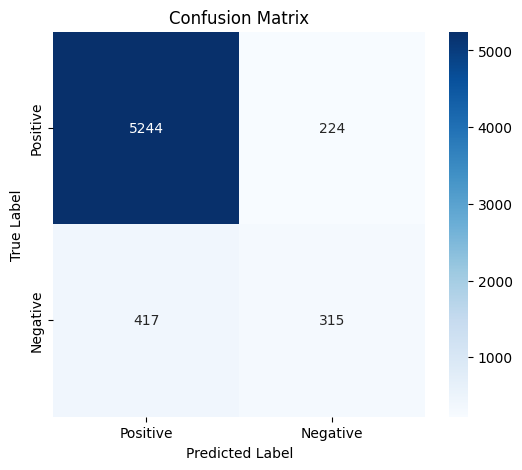


--- 성능 지표 ---
정밀도 (Precision): 0.9263
재현율 (Recall): 0.9590
F1-Score (직접 계산): 0.9424
F2-Score : 0.9523117713289506
F0.5-Score : 0.932697780307342


In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def f2_score_from_confusion_matrix(tp, fp, fn):
    """
    True Positives (TP), False Positives (FP), False Negatives (FN)를
    사용하여 F2-score를 계산합니다.
    """
    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)

    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)
        
    if 4 * precision + recall == 0:
        return 0
    
    f2 = 5 * (precision * recall) / (4 * precision + recall)
    return f2

def f0_5_score_from_confusion_matrix(tp, fp, fn):
    """
    True Positives (TP), False Positives (FP), False Negatives (FN)를
    사용하여 F-0.5 score를 계산합니다.
    """
    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)

    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)
        
    if 0.25 * precision + recall == 0:
        return 0
    
    f0_5 = 1.25 * (precision * recall) / (0.25 * precision + recall)
    return f0_5

def plot_and_calculate_metrics():
    confusion_matrix_data = np.array([[tp, fn], [fp, tn]])

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix_data, 
                annot=True,      # 각 셀에 숫자 표시
                fmt='d',         # 숫자를 정수 형태로 표시
                cmap='Blues',    # 색상 맵
                xticklabels=['Positive', 'Negative'], 
                yticklabels=['Positive', 'Negative'])
    
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # 그래프를 화면에 보여주기
    print("Confusion Matrix를 생성합니다.")
    plt.show()


    if (tp + fp) == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)
        
    if (tp + fn) == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)
    
    if (precision + recall) == 0:
        f1 = 0.0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)
    
    print("\n--- 성능 지표 ---")
    print(f"정밀도 (Precision): {precision:.4f}")
    print(f"재현율 (Recall): {recall:.4f}")
    print(f"F1-Score (직접 계산): {f1:.4f}")

plot_and_calculate_metrics()
print(f'F2-Score : {f2_score_from_confusion_matrix(tp,fp,fn)}')
print(f'F0.5-Score : {f0_5_score_from_confusion_matrix(tp,fp,fn)}')

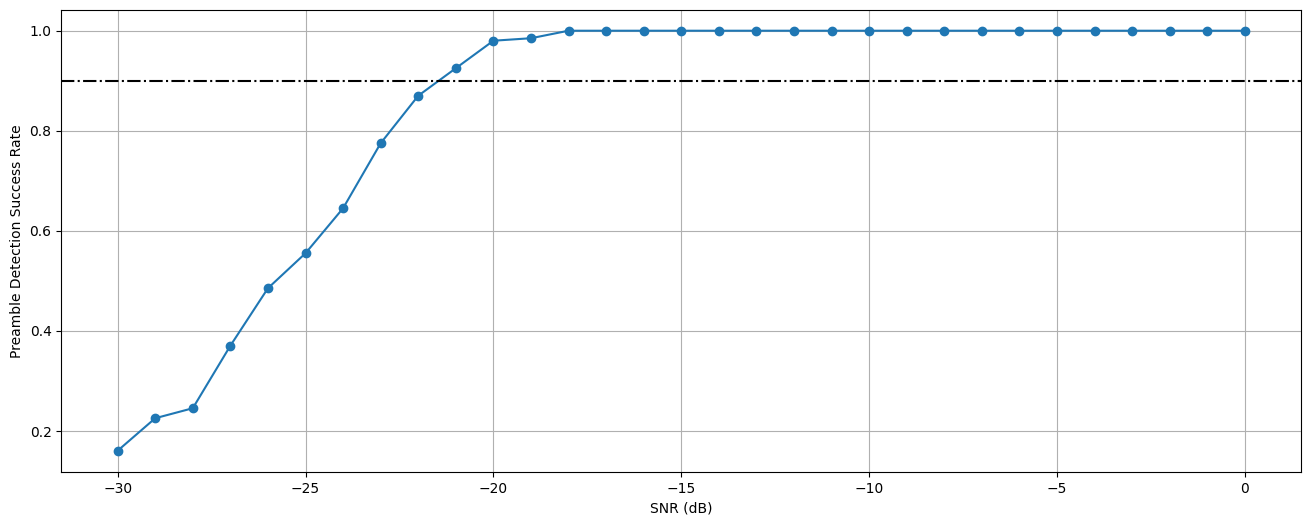

In [55]:
keys = sorted(pd_result.keys())
data = [pd_result_pred[k] for k in keys]
counts = [np.sum(np.array(row) == 1) for row in data]

plt.figure(figsize=(16,6))
plt.plot(keys, np.array(counts) / int(len(mat_files)/31), marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Preamble Detection Success Rate")
plt.axhline(0.9, linestyle='-.', color='black')
plt.grid(True)
plt.show()

df = pd.DataFrame({
    "key": np.asarray(keys, dtype=int),
    "ratio": np.asarray(counts, dtype=float) / int(len(mat_files)/31)
})
# df.to_csv(f"PD_{opts.sf}_ver2.csv", index=False)

## Computational Complexity

In [61]:
from torchinfo import summary
from thop import profile
input_size = (1,1,int(2**opts.sf),int(33*20))

print("=== Preamble Detector Summary ===")
summary(model, input_size=input_size)

=== Preamble Detector Summary ===


Layer (type:depth-idx)                   Output Shape              Param #
PreambleDetectorV2                       [1, 660]                  --
├─ColumnNetV2: 1-1                       [1, 128, 660]             --
│    └─Sequential: 2-1                   [1, 64, 128, 660]         --
│    │    └─Conv2d: 3-1                  [1, 16, 128, 660]         144
│    │    └─BatchNorm2d: 3-2             [1, 16, 128, 660]         32
│    │    └─ReLU: 3-3                    [1, 16, 128, 660]         --
│    │    └─DSBlock: 3-4                 [1, 16, 128, 660]         528
│    │    └─DSBlock: 3-5                 [1, 32, 128, 660]         816
│    │    └─DSBlock: 3-6                 [1, 64, 128, 660]         2,656
│    └─AdaptiveMaxPool2d: 2-2            [1, 64, 1, 660]           --
│    └─AdaptiveAvgPool2d: 2-3            [1, 64, 1, 660]           --
├─TemporalTCN: 1-2                       [1, 660]                  --
│    └─Sequential: 2-4                   [1, 128, 660]             --
│    │   

In [62]:
dummy_input = torch.randn(1, 1, int(2**opts.sf), 33*20).to(device)

macs_pd, params_pd = profile(model, inputs=(dummy_input, ), verbose=False)
flops_pd = macs_pd * 2  # 보통 1 MAC (곱하고 더하기) = 2 FLOPs로 계산합니다.

print(f"=== Model Performance Metrics (Preamble Detector) ===")
print(f"Params: {params_pd / 1e6:.2f} M (백만 개)")
print(f"MACs:   {macs_pd / 1e9:.4f} G (십억 회)")
print(f"FLOPs:  {flops_pd / 1e9:.4f} G (십억 회)")

=== Model Performance Metrics (Preamble Detector) ===
Params: 0.25 M (백만 개)
MACs:   0.5438 G (십억 회)
FLOPs:  1.0877 G (십억 회)


In [64]:
def check_storage_overhead(model, pth_file_path=None):
    """
    모델의 Storage Overhead(MB)를 계산하는 함수
    - model: PyTorch 모델 객체
    - pth_file_path: 저장된 .pth 파일 경로 (선택 사항)
    """
    
    # 1. 이론적 크기 계산 (RAM에 올라가는 순수 가중치 크기)
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size() # float32 = 4 bytes
        
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_all_bytes = param_size + buffer_size
    size_all_mb = size_all_bytes / (1024 * 1024)

    print(f"[{model.__class__.__name__}] Storage Analysis")
    print(f"------------------------------------------------")
    print(f"1. Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params")
    print(f"2. Theoretical Size (Memory): {size_all_mb:.2f} MB")

    # 2. 물리적 크기 확인 (실제 디스크 점유 용량)
    if pth_file_path and os.path.exists(pth_file_path):
        file_size_mb = os.path.getsize(pth_file_path) / (1024 * 1024)
        print(f"3. Physical File Size (.pth): {file_size_mb:.2f} MB")
    else:
        print("3. Physical File Size: (Path not provided or file not found)")
    
    print(f"------------------------------------------------\n")
    return size_all_mb

check_storage_overhead(model, f'../ckpt_sf{opts.sf}/best_{0.5}_{0.5}.pth')

[PreambleDetectorV2] Storage Analysis
------------------------------------------------
1. Parameters: 251,345 params
2. Theoretical Size (Memory): 0.96 MB
3. Physical File Size (.pth): 0.07 MB
------------------------------------------------



0.9648475646972656

In [65]:
import time
def measure_inference_robust(model, input_shape, device, repetitions=300, warmup=50):
    """
    논문용 정밀 Inference Time 측정 함수
    - model: 측정할 모델
    - input_shape: 입력 데이터 크기 (예: (1, 2, int(2**opts.sf), 33))
    - repetitions: 측정 반복 횟수 (많을수록 신뢰도 상승)
    - warmup: 예열 횟수
    """
    # 1. 모델 준비
    # model.to(device)
    # model.eval()
    
    # 2. 더미 데이터 준비
    dummy_input = torch.randn(input_shape).to(device)
    
    # 3. 타이머 설정 (GPU vs CPU 분기)
    if device.type == 'cuda':
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    
    # 4. [Warm-up] 초기 느린 구간 건너뛰기
    print(f"Warming up ({warmup} runs)...")
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)
    
    # 5. [Measurement] 실제 측정
    timings = np.zeros((repetitions, 1))
    print(f"Measuring ({repetitions} runs)...")
    
    with torch.no_grad():
        for rep in range(repetitions):
            if device.type == 'cuda':
                starter.record()
                _ = model(dummy_input)
                ender.record()
                # GPU 동기화 대기
                torch.cuda.synchronize()
                curr_time = starter.elapsed_time(ender) # 밀리초(ms) 단위 반환
                timings[rep] = curr_time
            else:
                # CPU의 경우 time 모듈 사용
                start_time = time.perf_counter()
                _ = model(dummy_input)
                end_time = time.perf_counter()
                timings[rep] = (end_time - start_time) * 1000 # 초 -> 밀리초 변환

    # 6. 통계 계산
    mean_time = np.mean(timings)
    std_time = np.std(timings)
    fps = 1000 / mean_time
    
    print(f"\n[{model.__class__.__name__}] 결과 리포트")
    print(f"--------------------------------------------------")
    print(f"평균 추론 시간 (Latency): {mean_time:.4f} ms")
    print(f"표준 편차 (Jitter)      : {std_time:.4f} ms")
    print(f"초당 프레임 수 (FPS)    : {fps:.2f} frames/sec")
    print(f"--------------------------------------------------")
    
    return mean_time, std_time

In [66]:
# 1. NELoRa 측정
input_shape = (1, 1, int(2**opts.sf), 33*20) # 본인 모델에 맞게 수정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(">>> Preamble Detector 측정 중...")
pd_model = model
measure_inference_robust(pd_model, input_shape, device, repetitions=1000)

>>> Preamble Detector 측정 중...
Warming up (50 runs)...
Measuring (1000 runs)...

[PreambleDetectorV2] 결과 리포트
--------------------------------------------------
평균 추론 시간 (Latency): 1.8600 ms
표준 편차 (Jitter)      : 0.1859 ms
초당 프레임 수 (FPS)    : 537.64 frames/sec
--------------------------------------------------


(1.8599843500852584, 0.18585214226674301)